In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [138]:
from sklearn.datasets import make_blobs
X,y = make_blobs(n_samples=1000,centers=3,n_features=2,random_state=42)

In [139]:
X

array([[-6.59633932, -7.13901457],
       [-6.13753182, -6.58081701],
       [ 5.19820575,  2.04917508],
       ...,
       [ 3.69047995,  4.60555175],
       [ 4.03036663,  1.78619838],
       [-7.44179522, -7.08933147]], shape=(1000, 2))

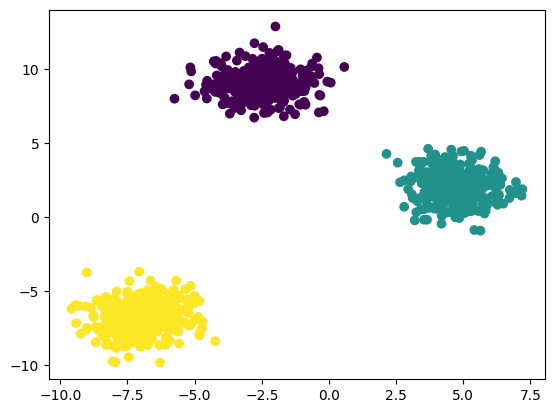

In [140]:
plt.scatter(X[:,0],X[:,1],c=y)

In [141]:
## standardization --features scalling technique
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [142]:
## train test and split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

In [143]:
X_train_scaled = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [144]:
from sklearn.cluster import KMeans

In [145]:
## elbow method to select the value of K
wcss = []
for k in range(1,11):
    kmeans= KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

c:\Users\manis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\manis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\manis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\manis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

In [146]:
wcss

[1339.9999999999998,
 424.77950428412703,
 43.53781728348885,
 38.44198058174099,
 32.62604606661915,
 25.84812908708551,
 23.855230041021464,
 24.587862766131927,
 19.948886789930786,
 17.996326473399606]

Text(0, 0.5, 'wcss')

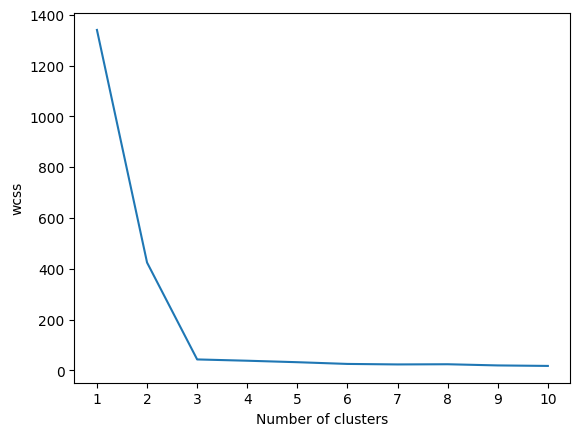

In [147]:
### plot elbow curvve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("wcss")

In [148]:
kmeans = KMeans(n_clusters=3,init="k-means++")

In [149]:
kmeans.fit_predict(X_train_scaled)

c:\Users\manis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


array([2, 1, 2, 0, 1, 2, 2, 0, 2, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 2, 0,
       1, 0, 0, 2, 1, 0, 0, 1, 0, 1, 1, 1, 0, 2, 0, 2, 2, 1, 1, 1, 0, 2,
       2, 0, 2, 2, 0, 1, 1, 0, 1, 2, 1, 0, 1, 2, 0, 2, 1, 2, 2, 2, 2, 0,
       1, 1, 1, 2, 2, 1, 1, 2, 0, 0, 2, 1, 0, 2, 1, 1, 1, 1, 1, 1, 2, 0,
       0, 0, 0, 1, 2, 0, 0, 1, 0, 0, 1, 2, 0, 2, 0, 2, 1, 0, 0, 1, 1, 2,
       0, 1, 0, 1, 0, 1, 0, 2, 2, 0, 0, 2, 0, 2, 2, 0, 2, 0, 2, 1, 2, 2,
       0, 2, 2, 1, 0, 0, 0, 1, 1, 2, 1, 0, 1, 2, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 2, 2, 2, 2, 1, 2, 2, 2, 0, 1, 1, 1, 2, 1, 1, 2, 2, 2,
       2, 2, 0, 0, 2, 2, 0, 2, 1, 1, 2, 1, 2, 1, 2, 0, 1, 1, 0, 0, 1, 0,
       2, 2, 0, 2, 0, 2, 0, 1, 1, 1, 0, 2, 0, 0, 1, 1, 1, 2, 2, 0, 1, 2,
       1, 1, 2, 0, 1, 2, 2, 0, 0, 0, 1, 1, 2, 2, 2, 2, 1, 0, 2, 1, 0, 1,
       1, 1, 2, 0, 1, 1, 0, 1, 2, 0, 0, 1, 0, 0, 2, 2, 1, 1, 0, 1, 0, 1,
       2, 0, 2, 2, 0, 2, 0, 1, 1, 2, 0, 1, 2, 2, 1, 2, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 2, 1, 0, 0, 1, 1, 1, 1, 2, 0,

In [150]:
y_pred = kmeans.predict(X_test)

In [151]:
y_pred

array([0, 1, 1, 2, 0, 1, 2, 0, 2, 0, 0, 2, 0, 0, 0, 1, 1, 2, 1, 1, 1, 0,
       0, 2, 2, 2, 1, 0, 2, 0, 1, 2, 2, 1, 2, 2, 2, 1, 0, 2, 0, 1, 1, 2,
       0, 1, 2, 2, 0, 1, 2, 0, 0, 2, 1, 1, 0, 0, 1, 2, 2, 0, 1, 2, 1, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 2, 1, 1, 1, 1, 2, 0, 1, 1, 2, 1, 1, 2, 1,
       1, 2, 1, 1, 0, 1, 1, 1, 2, 0, 1, 2, 0, 0, 1, 0, 1, 1, 0, 0, 1, 2,
       2, 2, 0, 1, 2, 1, 0, 0, 2, 1, 2, 1, 0, 2, 2, 0, 0, 0, 1, 1, 2, 2,
       1, 1, 0, 1, 0, 0, 0, 2, 0, 0, 2, 2, 1, 1, 0, 1, 1, 1, 2, 0, 1, 2,
       0, 0, 1, 1, 2, 2, 2, 0, 1, 2, 0, 1, 1, 0, 1, 1, 2, 0, 1, 2, 2, 2,
       0, 2, 1, 2, 0, 2, 1, 2, 2, 2, 0, 2, 2, 1, 0, 0, 0, 1, 2, 0, 1, 0,
       1, 0, 2, 0, 2, 2, 0, 0, 0, 2, 1, 0, 0, 0, 1, 2, 1, 2, 2, 0, 1, 2,
       2, 2, 1, 2, 1, 2, 1, 0, 0, 0, 0, 2, 2, 1, 0, 1, 1, 2, 2, 1, 0, 2,
       1, 1, 1, 0, 0, 0, 2, 0, 0, 0, 2, 0, 2, 2, 0, 0, 2, 1, 1, 2, 0, 2,
       0, 1, 2, 1, 1, 2, 0, 2, 1, 2, 2, 2, 2, 0, 0, 2, 2, 1, 2, 1, 1, 2,
       1, 1, 2, 2, 2, 0, 0, 2, 2, 2, 1, 2, 2, 2, 1,

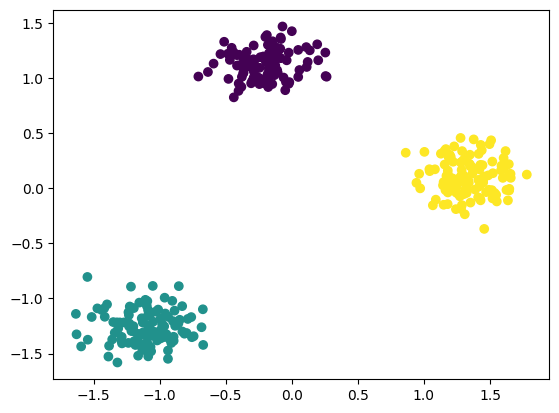

In [152]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [153]:
## Validating the k value
## kneelocator
## Silhoutee scoring

In [154]:
from kneed import KneeLocator

In [155]:
kl = KneeLocator(
    range(1, 11),
    wcss,
    curve="convex",
    direction="decreasing"
)

In [156]:
kl.elbow

np.int64(3)

In [157]:
## silhoutte score
from sklearn.metrics import silhouette_score    

In [158]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

c:\Users\manis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\manis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\manis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\manis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

In [159]:
silhouette_coefficients

[0.6857199772837788,
 0.842476016737992,
 0.6772992476858807,
 0.5206293210832283,
 0.49374827319840847,
 0.34442014860789705,
 0.33908261291438874,
 0.34406910823921966,
 0.3269402215648185]

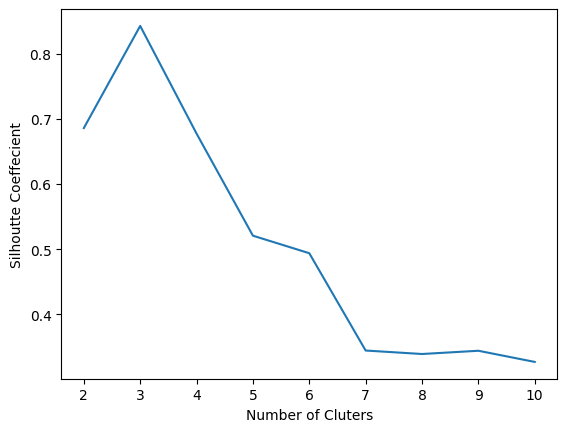

In [160]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()